Aqui va todo de lo que estoy seguro de usar

In [1]:
from limpio import *
import numpy as np
from sklearn.preprocessing import RobustScaler
from keras.callbacks import EarlyStopping

In [2]:
MINUTES = 30

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4518540
✅ Agregado: 5min | Filas: 915307
✅ Agregado: 15min | Filas: 306022
✅ Agregado: 30min | Filas: 154771
✅ Agregado: 60min | Filas: 78017


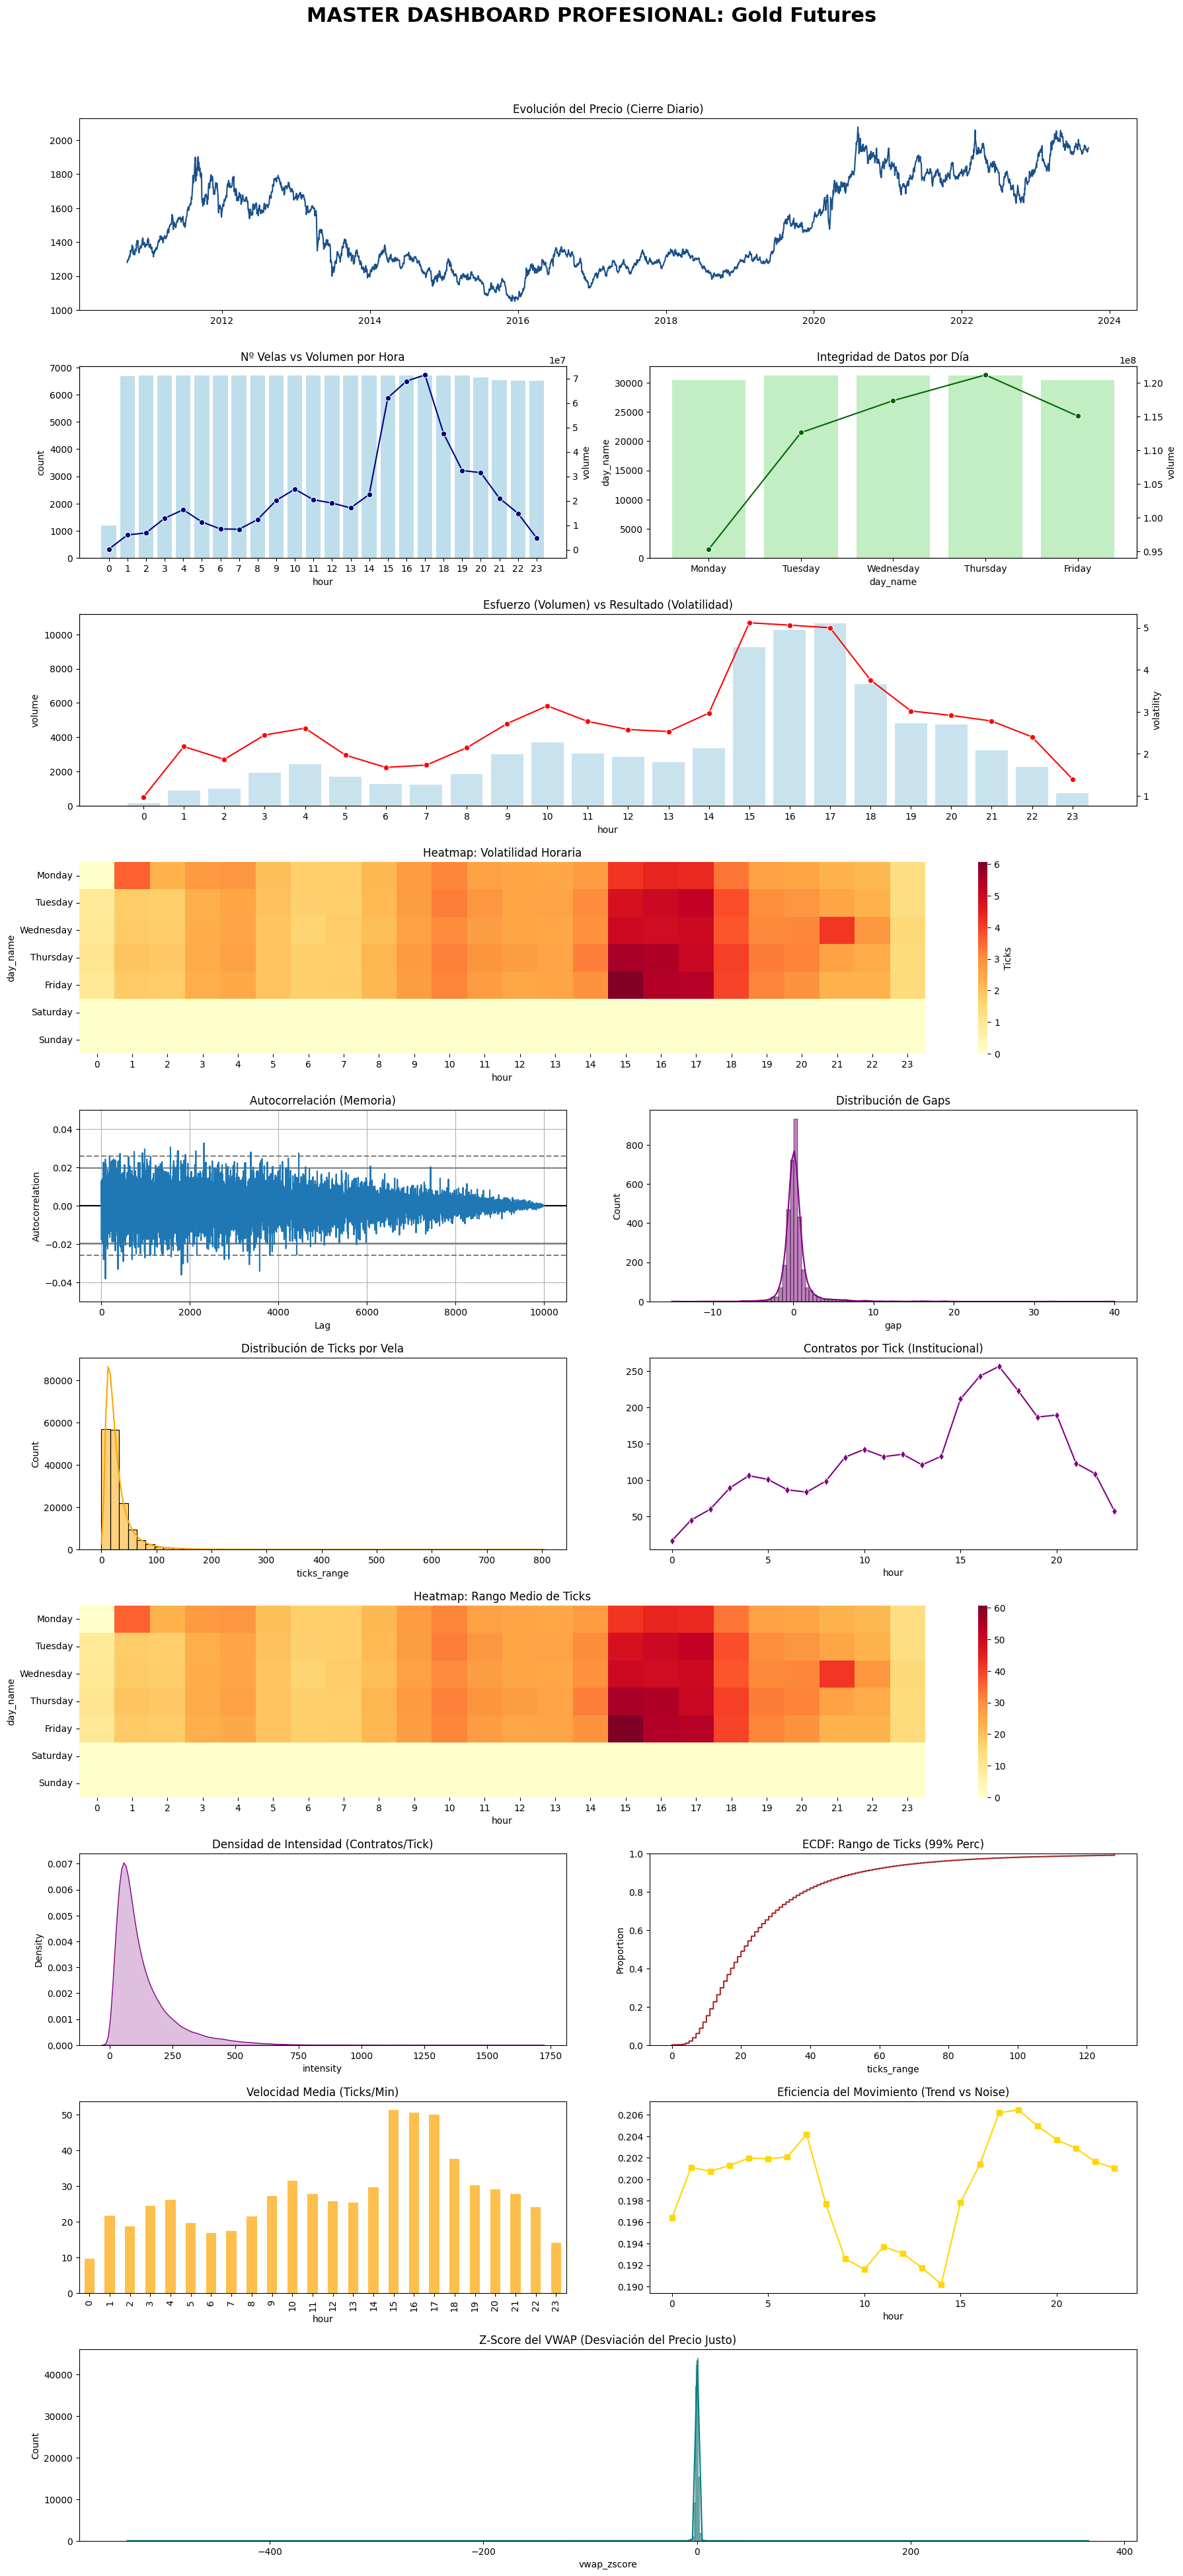

In [3]:
df_min, spec = import_dataset()
df_min_clean = clean(df_min)
df_resampled = get_multitimeframe_data(df_min_clean)
plot_master_market_analysis(df_resampled[f'{MINUTES}min'], asset_name="Gold Futures", tick_size=0.1)

In [4]:
df_cumulative = apply_cumulative_stats_to_dict(df_resampled)

✅ Procesados acumulados diarios para: 5min
✅ Procesados acumulados diarios para: 15min
✅ Procesados acumulados diarios para: 30min
✅ Procesados acumulados diarios para: 60min


In [5]:
df_final_dict = process_full_dictionary(df_cumulative, spec)

🚀 Features generadas para 5min: 48 columnas.
🚀 Features generadas para 15min: 48 columnas.
🚀 Features generadas para 30min: 48 columnas.
🚀 Features generadas para 60min: 48 columnas.


In [6]:
df_final_dict[f'{MINUTES}min'].iloc[0]

datetime               2010-09-20 17:00:00
open                                1279.6
high                                1283.9
low                                 1279.4
close                               1282.9
volume                                6861
openint                                0.0
ticker                                  GC
per                                  30min
trading_date                    2010-09-20
open_day                            1279.8
high_cum                            1284.9
low_cum                             1278.3
volume_cum                           35188
dist_to_high                           2.0
dist_to_low                            4.6
step_sin                         -0.965926
step_cos                         -0.258819
dow_sin                                0.0
dow_cos                                1.0
is_london                                0
is_ny                                    1
is_overlap                               0
body_ticks 

In [7]:
FEATURE_COLUMNS = [
    # --- Ciclos y Tiempo ---
    'step_sin', 'step_cos', 'dow_sin', 'dow_cos',
    
    # --- Sesiones ---
    'is_london', 'is_ny', 'is_overlap',
    
    # --- Acción del Precio (Ticks) ---
    'body_pct', 'upper_wick_pct', 'lower_wick_pct', 'close_location',
    
    # --- Dinámica de Volumen ---
    'vol_per_tick', 'vol_vs_body', 'vol_weight_intraday',
    
    # --- Indicadores y Momentum ---
    'log_ret', 'rsi_14', 'volatility_20', 'efficiency_ratio',
    
    # --- Contexto y Valor ---
    'vwap_zscore', 'dist_sma_20_ticks', 'ticks_velocity',
    
    # --- Posición Diaria ---
    'dist_high_cum_ticks', 'dist_low_cum_ticks', 'dist_open_day_ticks'
]

TARGET_COLUMN = 'target_bin' # 1 si sube, 0 si baja/lateral

In [8]:
df_final_dict = audit_and_clean_dict(df_final_dict, FEATURE_COLUMNS)

--- 🔍 Auditando 5min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 15min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 30min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 60min ---
💎 Datos limpios. Sin NaNs.
-------------------------


In [15]:
results_pack = run_walk_forward_bin(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS)

c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🔄 Entrenando Ventana Binaria: 2010-09-20 17:00:00 --> 2014-01-20 03:00:00
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
✅ Ventana completada. Acc: 51.77% | Buy Ratio: 44.70%

🔄 Entrenando Ventana Binaria: 2011-07-20 09:30:00 --> 2014-11-17 18:30:00


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
✅ Ventana completada. Acc: 52.83% | Buy Ratio: 33.49%


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
✅ Ventana completada. Acc: 51.02% | Buy Ratio: 21.14%

🔄 Entrenando Ventana Binaria: 2018-04-04 11:30:00 --> 2021-08-20 18:00:00


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
✅ Ventana completada. Acc: 50.23% | Buy Ratio: 62.78%

🔄 Entrenando Ventana Binaria: 2019-02-06 17:00:00 --> 2022-06-24 22:30:00


c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
✅ Ventana completada. Acc: 50.99% | Buy Ratio: 45.63%


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class GoldLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super(GoldLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Capa LSTM
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout)
        
        # Normalización y Dropout
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        
        # Capas Densas
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        # Tomamos solo el último output de la secuencia (many-to-one)
        out = out[:, -1, :] 
        
        out = self.batch_norm(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out
def run_walk_forward_pytorch(df, feature_cols, target_col='target_bin', 
                             train_size=40000, test_size=10000, step=10000, 
                             lookback=20, epochs=15, batch_size=64):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ Ejecutando en: {device}")

    all_predictions = []
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)
    
    for start in range(0, len(df_wf) - train_size - test_size, step):
        end_train = start + train_size
        end_test = end_train + test_size
        
        # Segmentación y Escalado
        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()
        
        scaler = RobustScaler()
        train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = scaler.transform(test_df[feature_cols])
        
        # Crear Tensores (Usando tu función strides)
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)
        
        # Convertir a Tensores de PyTorch y mover a DEVICE
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        
        # DataLoader para entrenamiento eficiente
        dataset = TensorDataset(X_train_t, y_train_t)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # Inicializar Modelo, Loss y Optimizer
        model = GoldLSTM(input_dim=len(feature_cols)).to(device)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        
        # --- Bucle de Entrenamiento ---
        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        
        # --- Predicción ---
        model.eval()
        with torch.no_grad():
            probs = model(X_test_t).cpu().numpy().ravel()
            pred_classes = (probs > 0.5).astype(int)
        
        # Recopilar resultados
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback : end_test].values,
            'actual': y_test,
            'pred': pred_classes,
            'prob_up': probs,
            'ret_real': df_wf['target_ret_30m'].iloc[end_train + lookback : end_test].values
        })
        
        all_predictions.append(res_df)
        acc = (pred_classes == y_test).mean()
        print(f"✅ Ventana {df_wf['datetime'].iloc[start].date()}: Acc {acc:.2%}")

    return pd.concat(all_predictions, ignore_index=True)

In [26]:
from torch.cuda.amp import autocast, GradScaler 

def run_walk_forward_pytorch_amp(df, feature_cols, target_col='target_bin', 
                                 train_size=40000, test_size=10000, step=10000, 
                                 lookback=20, epochs=15, batch_size=256): # Subimos batch_size
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ Usando GPU: {torch.cuda.get_device_name(0)} con AMP")

    # Inicializamos el escalador de gradientes para AMP
    scaler_amp = GradScaler() 
    all_predictions = []
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)
    
    for start in range(0, len(df_wf) - train_size - test_size, step):
        end_train = start + train_size
        end_test = end_train + test_size
        
        # --- Preprocesado y Escalado ---
        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()
        
        sc = RobustScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = sc.transform(test_df[feature_cols])
        
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)
        
        # Tensores con pin_memory para velocidad de transferencia
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        
        loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        model = GoldLSTM(input_dim=len(feature_cols)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        criterion = nn.BCEWithLogitsLoss()
        
        # --- Bucle Entrenamiento con AMP ---
        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                
                # Cast automático a Float16 donde sea seguro
                with autocast():
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                
                # Escalar la pérdida para evitar "gradient underflow"
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
        
        # --- Predicción (Siempre en Float32 para máxima precisión) ---
        model.eval()
        with torch.no_grad():
            logits = model(X_test_t)
            # Como el modelo ya no tiene Sigmoid, se lo aplicamos aquí manualmente
            probs = torch.sigmoid(logits).cpu().numpy().ravel() 
            pred_classes = (probs > 0.5).astype(int)
        
        # Guardar resultados
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback : end_test].values,
            'actual': y_test,
            'pred': pred_classes,
            'prob_up': probs,
            'ret_real': df_wf['target_ret_30m'].iloc[end_train + lookback : end_test].values
        })
        
        all_predictions.append(res_df)
        print(f"✅ Ventana {df_wf['datetime'].iloc[start].date()} OK. Acc: {(pred_classes == y_test).mean():.2%}")

    return pd.concat(all_predictions, ignore_index=True)

In [27]:
result_torch = run_walk_forward_pytorch_amp(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS)

🖥️ Usando GPU: NVIDIA GeForce RTX 3060 Laptop GPU con AMP


C:\Users\LIJUN\AppData\Local\Temp\ipykernel_7300\1632654384.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = GradScaler()
C:\Users\LIJUN\AppData\Local\Temp\ipykernel_7300\1632654384.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2010-09-20 OK. Acc: 51.96%


C:\Users\LIJUN\AppData\Local\Temp\ipykernel_7300\1632654384.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2011-07-20 OK. Acc: 53.65%


...

✅ Ventana 2017-05-30 OK. Acc: 50.62%


C:\Users\LIJUN\AppData\Local\Temp\ipykernel_7300\1632654384.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2018-04-04 OK. Acc: 50.86%


C:\Users\LIJUN\AppData\Local\Temp\ipykernel_7300\1632654384.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2019-02-06 OK. Acc: 51.77%


In [25]:
from tqdm.auto import tqdm # Auto detecta si estás en consola o Jupyter
import torch.cuda.amp as amp

def run_walk_forward_tqdm(df, feature_cols, target_col='target_bin', 
                          train_size=40000, test_size=10000, step=10000, 
                          lookback=20, epochs=15, batch_size=256):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    scaler_amp = amp.GradScaler()
    all_predictions = []
    
    # 1. Calculamos el número total de ventanas para la barra de progreso
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)
    n_windows = (len(df_wf) - train_size - test_size) // step + 1
    
    # --- BARRA DE PROGRESO MAESTRA (Ventanas) ---
    pbar_windows = tqdm(range(0, len(df_wf) - train_size - test_size, step), 
                        total=n_windows, desc="🚀 Walk-Forward Progress")

    for start in pbar_windows:
        end_train = start + train_size
        end_test = end_train + test_size
        
        # Segmentación y Escalado
        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()
        
        sc = RobustScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = sc.transform(test_df[feature_cols])
        
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)
        
        # Pasar a tensores
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        
        loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        model = GoldLSTM(input_dim=len(feature_cols)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        criterion = nn.BCEWithLogitsLoss()
        
        # --- Entrenamiento ---
        model.train()
        # Puedes añadir descripición dinámica a la pbar maestra
        pbar_windows.set_postfix({"Window_Start": df_wf['datetime'].iloc[start].date()})
        
        for epoch in range(epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                with amp.autocast():
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
        
        # --- Predicción ---
        model.eval()
        with torch.no_grad():
            logits = model(X_test_t)
            # Como el modelo ya no tiene Sigmoid, se lo aplicamos aquí manualmente
            probs = torch.sigmoid(logits).cpu().numpy().ravel() 
            pred_classes = (probs > 0.5).astype(int)
        
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback : end_test].values,
            'actual': y_test,
            'pred': pred_classes,
            'prob_up': probs,
            'ret_real': df_wf['target_ret_30m'].iloc[end_train + lookback : end_test].values
        })
        
        all_predictions.append(res_df)
        
        # Limpiar caché de CUDA para evitar fragmentación en la 3060
        torch.cuda.empty_cache()

    return pd.concat(all_predictions, ignore_index=True)

c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


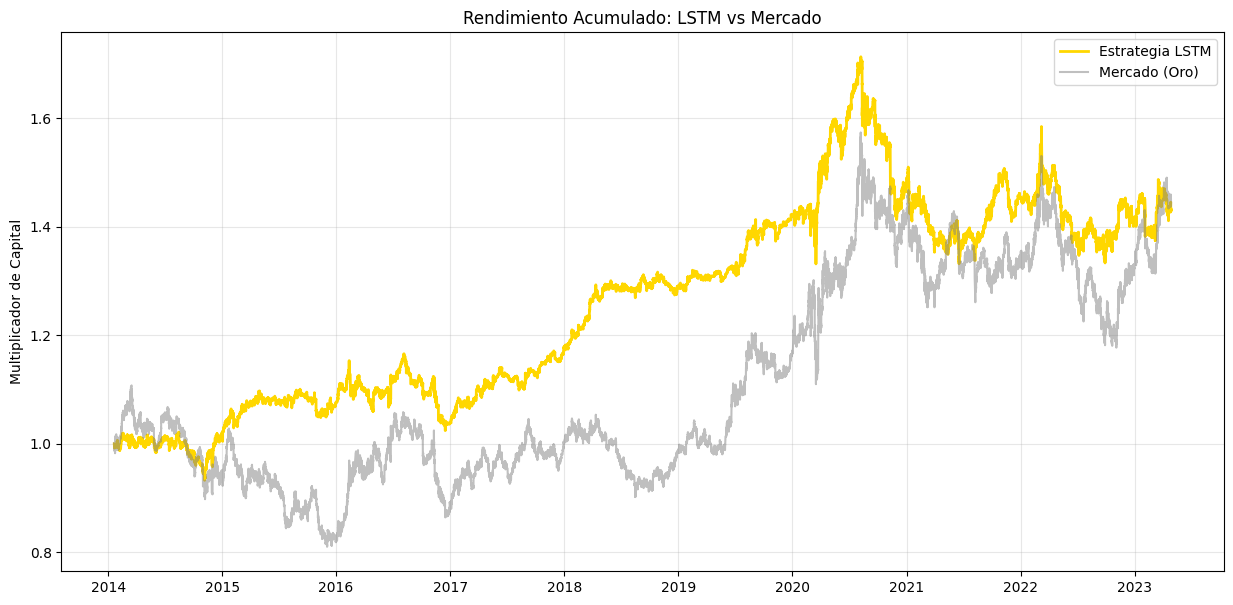

💰 Sharpe Ratio Estimado: 0.07
📈 Retorno Total Estrategia: 43.25%


In [28]:
import matplotlib.pyplot as plt

def plot_trading_results(df_res):
    # 1. Calculamos el retorno de la estrategia
    # Si la probabilidad es > 0.5, compramos (usamos el retorno real)
    # Si es < 0.5, no hacemos nada (o podrías vender, pero vamos a probar solo largos)
    df_res['strat_ret'] = df_res.apply(lambda x: x['ret_real'] if x['prob_up'] > 0.5 else 0, axis=1)
    
    # 2. Retorno acumulado
    df_res['cum_strat'] = (1 + df_res['strat_ret']).cumprod()
    df_res['cum_market'] = (1 + df_res['ret_real']).cumprod()
    
    # 3. Gráfico
    plt.figure(figsize=(15, 7))
    plt.plot(df_res['datetime'], df_res['cum_strat'], label='Estrategia LSTM', color='gold', lw=2)
    plt.plot(df_res['datetime'], df_res['cum_market'], label='Mercado (Oro)', color='gray', alpha=0.5)
    
    plt.title('Rendimiento Acumulado: LSTM vs Mercado')
    plt.ylabel('Multiplicador de Capital')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 4. Estadísticas Pro
    sharpe = (df_res['strat_ret'].mean() / df_res['strat_ret'].std()) * (252**0.5)
    print(f"💰 Sharpe Ratio Estimado: {sharpe:.2f}")
    print(f"📈 Retorno Total Estrategia: {(df_res['cum_strat'].iloc[-1]-1):.2%}")

plot_trading_results(result_torch)